In [ ]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
# -----------------------------
# Imports
# -----------------------------
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
# =========================================================
# Dataset and Configurations
# =========================================================
df = pd.read_csv("creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

TEST_SIZE = 0.2
RANDOM_STATE = 42
KFOLD_SPLITS = 5
CUSTOM_THRESH = 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Global Parameters
XGB_RANDOM_STATE = 42
XGB_N_ITER = 24
XGB_PARAM_SPACE = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "gamma": [0.0, 0.1, 0.5, 1.0]
}

In [ ]:
# =========================================================
# Build GPU XGBoost Classifier
# =========================================================
def build_xgb_gpu(scale_pos_weight=1.0,
                  n_estimators=500, max_depth=6, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                  reg_lambda=1.0, reg_alpha=0.0, gamma=0.0):
    """
    Builds an XGBoost model configured for GPU training using the given parameters.
    """
    print(f"Building XGB (GPU): spw={scale_pos_weight:.2f}, "
          f"n={n_estimators}, depth={max_depth}, eta={learning_rate}, "
          f"sub={subsample}, col={colsample_bytree}, mcw={min_child_weight}, "
          f"lambda={reg_lambda}, alpha={reg_alpha}, gamma={gamma}")
    return XGBClassifier(
        tree_method="hist",
        device="cuda",
        random_state=XGB_RANDOM_STATE,
        eval_metric="auc",
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        gamma=gamma,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    )

# =========================================================
# Cross-validation (ROC-AUC based)
# =========================================================
def cross_validate_proba(model_builder, X, y, kfold):
    """
    Runs K-fold cross-validation for a model built by `model_builder`.
    Returns mean and standard deviation of ROC-AUC across folds.
    """
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

        model = model_builder()
        model.fit(Xtr, ytr)
        y_prob = model.predict_proba(Xval)[:, 1]
        auc_score = roc_auc_score(yval, y_prob)
        print(f"    Fold {fold}: ROC-AUC = {auc_score:.4f}")
        scores.append(auc_score)

    return np.mean(scores), np.std(scores)

# =========================================================
# Random Search for GPU XGBoost Hyperparameters
# =========================================================
def random_search_xgb_gpu(X, y, kfold, n_iter, param_space, random_state):
    """
    Randomly samples hyperparameters from the defined space,
    performs cross-validation, and returns the best model and parameters.
    """
    random.seed(random_state)
    np.random.seed(random_state)

    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    spw = neg / max(pos, 1)

    print("\n" + "="*60)
    print("GPU XGBOOST RANDOM SEARCH STARTED")
    print("="*60)
    print(f"[Info] Train positives: {pos}, negatives: {neg}, scale_pos_weight={spw:.2f}\n")

    best_score, best_params, best_builder = -1, None, None

    for i in range(n_iter):
        params = {
            "n_estimators": random.choice(param_space["n_estimators"]),
            "max_depth": random.choice(param_space["max_depth"]),
            "learning_rate": random.choice(param_space["learning_rate"]),
            "subsample": random.choice(param_space["subsample"]),
            "colsample_bytree": random.choice(param_space["colsample_bytree"]),
            "min_child_weight": random.choice(param_space["min_child_weight"]),
            "reg_lambda": random.choice(param_space["reg_lambda"]),
            "reg_alpha": random.choice(param_space["reg_alpha"]),
            "gamma": random.choice(param_space["gamma"]),
        }

        print(f"  Iter {i+1}/{n_iter}: {params}")

        def builder(params=params, spw=spw):
            return build_xgb_gpu(scale_pos_weight=spw, **params)

        mean_cv, std_cv = cross_validate_proba(builder, X, y, kfold)
        print(f"    CV ROC-AUC: {mean_cv:.4f} ± {std_cv:.4f}\n")

        if mean_cv > best_score:
            best_score, best_params, best_builder = mean_cv, params.copy(), builder

    print(f"Best Params Found: {best_params}, ROC-AUC={best_score:.4f}")

    best_model = best_builder()
    best_model.fit(X, y)
    return best_model, best_params

# =========================================================
# Evaluation Function
# =========================================================
def evaluate_gpu(model, X_test, y_test, label="Model", threshold=0.3):
    """
    Evaluates the trained GPU model (e.g., XGBoost) on test data.
    Prints and plots performance metrics including:
      - Confusion Matrix (heatmap)
      - ROC Curve
      - Precision–Recall Curve
      - F1 Score vs Threshold Curve
    """
    # Predict probabilities and binary predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Compute metrics
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else threshold

    # Print metrics
    print(f"\n{label} — Evaluation Metrics")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"PR-AUC Score:  {pr_auc:.4f}")
    print(f"Optimal Threshold (by F1): {best_thresh:.3f}  (F1={np.max(f1):.3f})")

    # 1. Confusion Matrix (Heatmap)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()

    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. Precision–Recall Curve
    plt.figure(figsize=(6, 5))
    plt.plot(rec, prec, lw=2, color="orange", label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4. F1 Score vs Threshold Curve
    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, f1[:-1], lw=2, color="green")
    plt.axvline(best_thresh, color="red", linestyle="--", label=f"Best = {best_thresh:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title(f"F1 Score vs Threshold — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return metrics
    return {
        "model": label,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": best_thresh
    }

# =========================================================
# Training Function with Balancing Methods
# =========================================================
def train_xgb_balance(X_train, y_train, X_test, y_test, balance_method="none", threshold=0.3):
    """
    Trains an XGBoost classifier with a chosen balancing method:
    - none
    - class_weight (via scale_pos_weight)
    - smote
    - smote_class_weight (hybrid)
    Performs its own random search and prints best parameters.
    """
    print("==============================================")
    print(f"GPU XGBOOST TRAINING STARTED ({balance_method.upper()})")
    print("==============================================")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=XGB_RANDOM_STATE)

    if balance_method == "smote":
        print("Applying SMOTE balancing...")
        sm = SMOTE(random_state=XGB_RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        scale_pos_weight = 1.0
    elif balance_method == "class_weight":
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        scale_pos_weight = neg / max(pos, 1)
        print(f"Using scale_pos_weight={scale_pos_weight:.2f}")
    elif balance_method == "smote_class_weight":
        print("Applying SMOTE + class_weight hybrid...")
        sm = SMOTE(random_state=XGB_RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        scale_pos_weight = neg / max(pos, 1)
    else:
        print("No balancing applied.")
        scale_pos_weight = 1.0

    model, best_params = random_search_xgb_gpu(
        X_train, y_train, kfold, n_iter=XGB_N_ITER,
        param_space=XGB_PARAM_SPACE, random_state=XGB_RANDOM_STATE
    )
    print(f"\nBest Parameters for {balance_method.upper()}: {best_params}")
    metrics = evaluate_gpu(model, X_test, y_test, label=f"XGBoost ({balance_method.upper()})", threshold=threshold)
    metrics["best_params"] = best_params
    return model, metrics

GPU XGBOOST TRAINING STARTED (NONE)
No balancing applied.

GPU XGBOOST RANDOM SEARCH STARTED
[Info] Train positives: 394, negatives: 227451, scale_pos_weight=577.29

  Iter 1/24: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'gamma': 1.0}
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [05:21:41] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


    Fold 1: ROC-AUC = 0.9961
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 2: ROC-AUC = 0.9769
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 3: ROC-AUC = 0.9686
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 4: ROC-AUC = 0.9963
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 5: ROC-AUC = 0.9802
    CV ROC-AUC: 0.9836 ± 0.0109

  Iter 2/24: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.02, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'gamma': 0.1}
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.02, sub=0.6, col=0.6, mcw=1, lambda=1.0, alpha=1.0, gamma=0.1
    Fold 1: ROC-AUC = 0.9929
Building XGB (GPU): sp

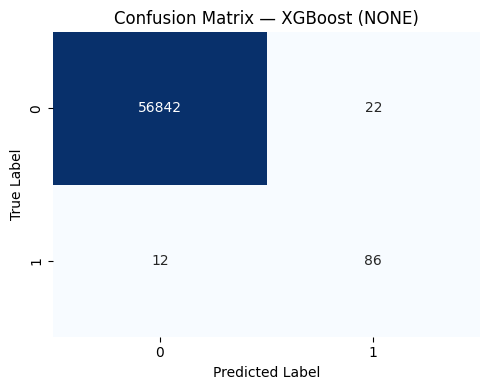

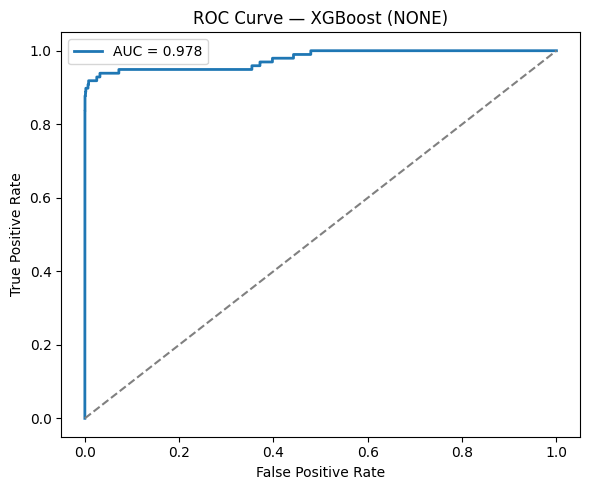

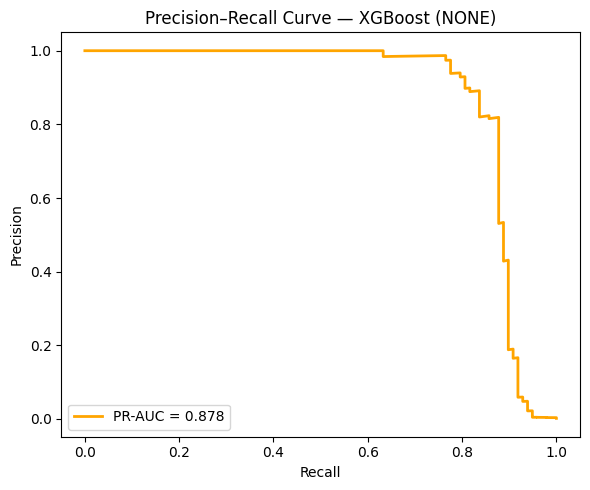

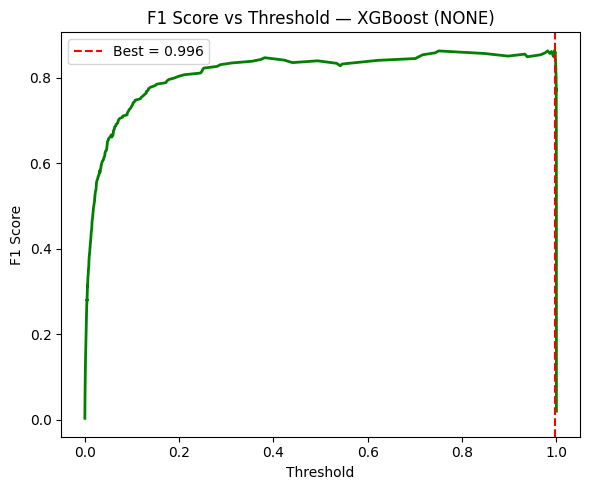

In [ ]:
# ================================================
# RUN 1 — NO BALANCING
# ================================================
xgb_none_model, xgb_none_metrics = train_xgb_balance(X_train, y_train, X_test, y_test, "none")

GPU XGBOOST TRAINING STARTED (CLASS_WEIGHT)
Using scale_pos_weight=577.29

GPU XGBOOST RANDOM SEARCH STARTED
[Info] Train positives: 394, negatives: 227451, scale_pos_weight=577.29

  Iter 1/24: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'gamma': 1.0}
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 1: ROC-AUC = 0.9961
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 2: ROC-AUC = 0.9769
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 3: ROC-AUC = 0.9686
Building XGB (GPU): spw=577.29, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 4: ROC-AUC = 0.9963
Building XGB (GPU): spw=577.29, n=300, depth=3,

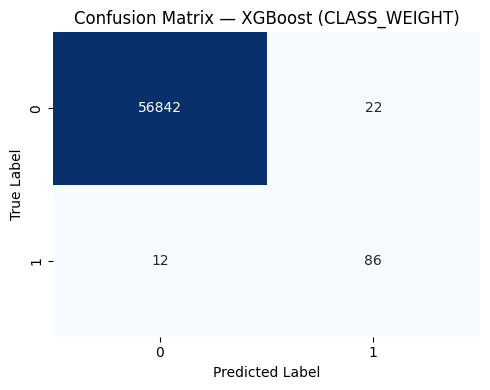

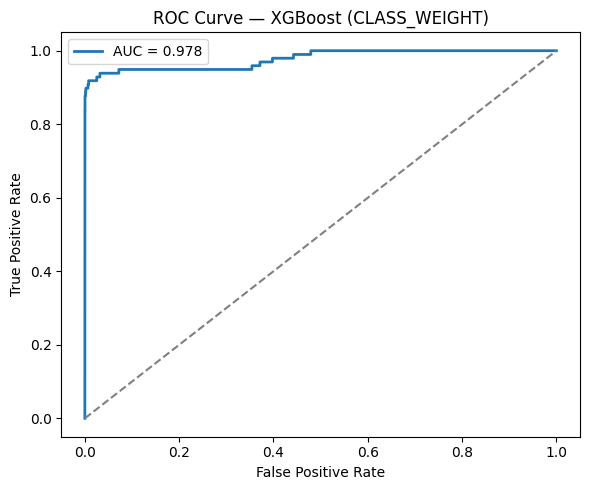

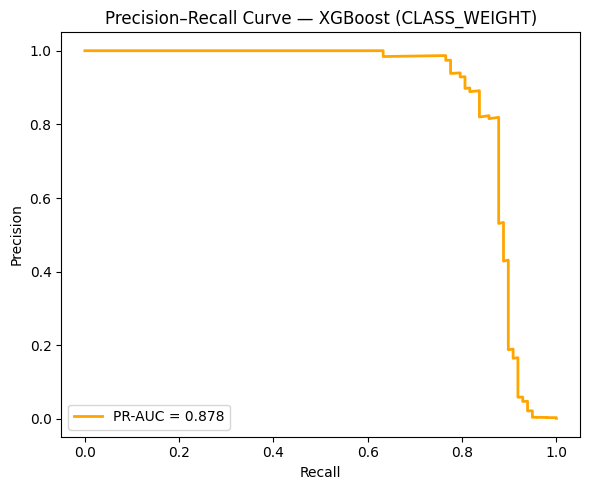

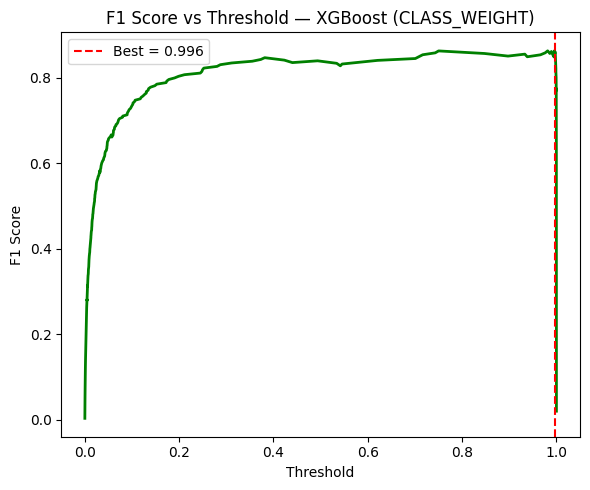

In [ ]:
# ================================================
# RUN 2 — CLASS WEIGHT
# ================================================
xgb_cw_model, xgb_cw_metrics = train_xgb_balance(X_train, y_train, X_test, y_test, "class_weight")

GPU XGBOOST TRAINING STARTED (SMOTE)
Applying SMOTE balancing...

GPU XGBOOST RANDOM SEARCH STARTED
[Info] Train positives: 227451, negatives: 227451, scale_pos_weight=1.00

  Iter 1/24: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'gamma': 1.0}
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 1: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 2: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 3: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 4: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6

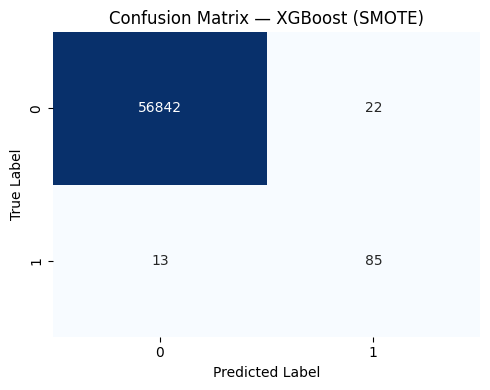

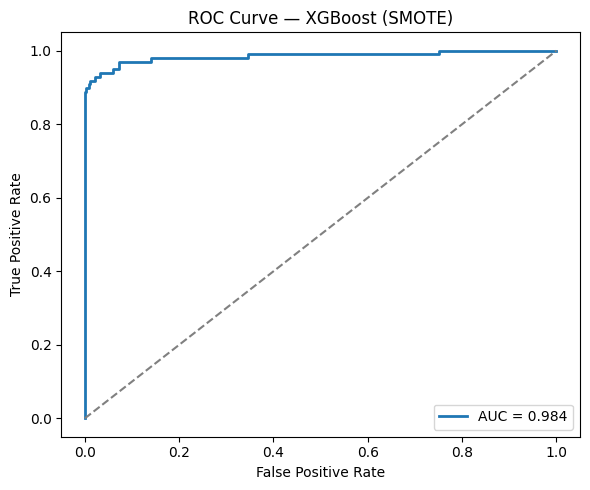

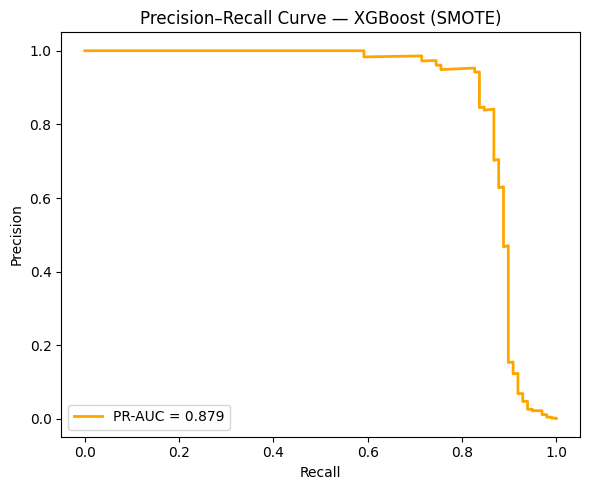

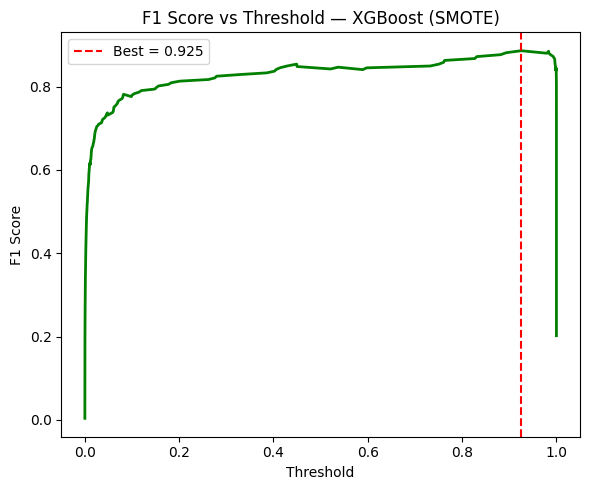

In [ ]:
# ================================================
# RUN 3 — SMOTE
# ================================================
xgb_smote_model, xgb_smote_metrics = train_xgb_balance(X_train, y_train, X_test, y_test, "smote")

GPU XGBOOST TRAINING STARTED (SMOTE_CLASS_WEIGHT)
Applying SMOTE + class_weight hybrid...

GPU XGBOOST RANDOM SEARCH STARTED
[Info] Train positives: 227451, negatives: 227451, scale_pos_weight=1.00

  Iter 1/24: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'gamma': 1.0}
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 1: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 2: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 3: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, depth=3, eta=0.05, sub=0.6, col=0.6, mcw=5, lambda=0.5, alpha=0.0, gamma=1.0
    Fold 4: ROC-AUC = 0.9998
Building XGB (GPU): spw=1.00, n=300, d

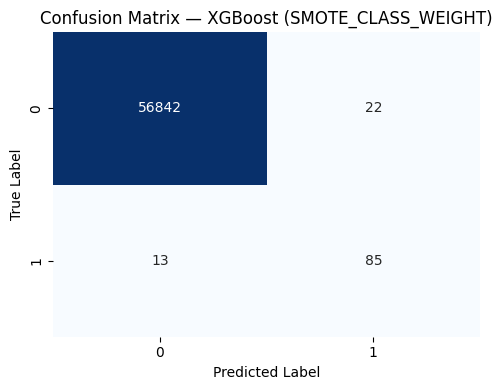

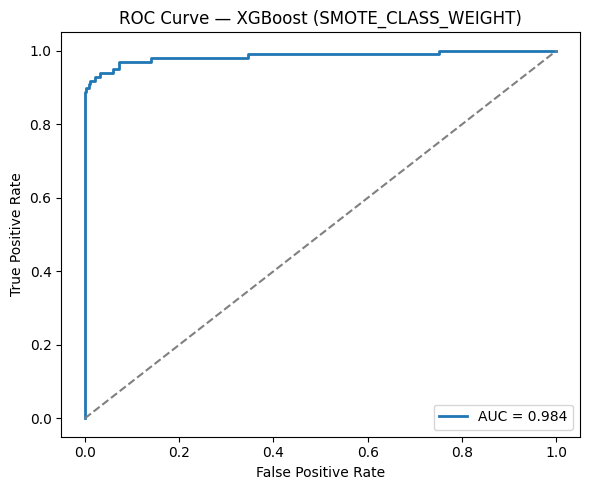

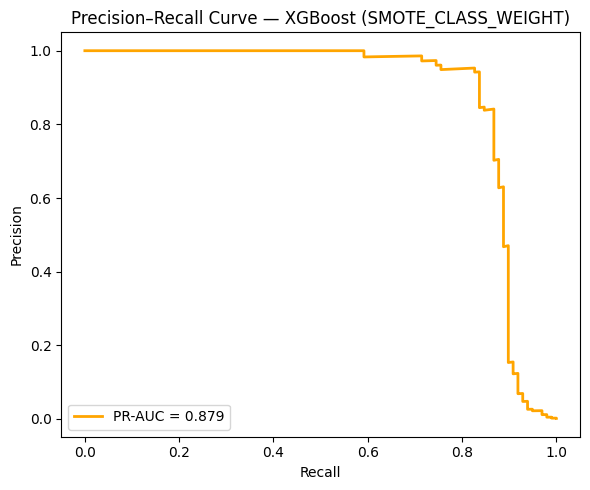

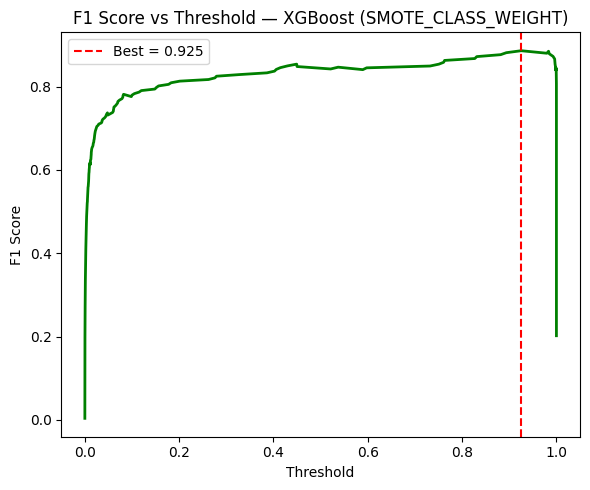

In [ ]:
# ================================================
# 🔹 RUN 4 — SMOTE + CLASS_WEIGHT
# ================================================
xgb_hybrid_model, xgb_hybrid_metrics = train_xgb_balance(X_train, y_train, X_test, y_test, "smote_class_weight")

In [ ]:
# =========================================================
# Results Summary
# =========================================================
results_df = pd.DataFrame([
    {"Model": "XGB — None", "ROC-AUC": xgb_none_metrics["roc_auc"], "PR-AUC": xgb_none_metrics["pr_auc"], "Best Params": xgb_none_metrics["best_params"]},
    {"Model": "XGB — Class Weight", "ROC-AUC": xgb_cw_metrics["roc_auc"], "PR-AUC": xgb_cw_metrics["pr_auc"], "Best Params": xgb_cw_metrics["best_params"]},
    {"Model": "XGB — SMOTE", "ROC-AUC": xgb_smote_metrics["roc_auc"], "PR-AUC": xgb_smote_metrics["pr_auc"], "Best Params": xgb_smote_metrics["best_params"]},
    {"Model": "XGB — SMOTE + Class Weight", "ROC-AUC": xgb_hybrid_metrics["roc_auc"], "PR-AUC": xgb_hybrid_metrics["pr_auc"], "Best Params": xgb_hybrid_metrics["best_params"]}
])

print("\n================== GPU XGBOOST RESULTS ==================")
print(results_df.to_string(index=False))


================== GPU XGBOOST RESULTS ==================
                     Model  ROC-AUC   PR-AUC                                                                                                                                                                         Best Params
                XGB — None 0.977606 0.877724 {'n_estimators': 1200, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 20, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'gamma': 0.5}
        XGB — Class Weight 0.977606 0.877724 {'n_estimators': 1200, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 20, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'gamma': 0.5}
               XGB — SMOTE 0.984495 0.878618   {'n_estimators': 1200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'gamma': 0.0}
XGB — SMOTE + Class Weight 0.984495 0.878